# **Практическая работа №6. Проектирование автоэнкодеров для решения прикладных задач**

[**Ссылка на код с пары**](https://colab.research.google.com/drive/1KfCEQly5k0PUdCR1w-my2-QmYfFexdvK?usp=sharing)

### - **N.B.: Во всех заданиях, графический интерфейс для взаимодействия с обученной моделью, реализуется с помощью Gradio!**

### - **Для каждого задания в графическом интерфейсе должно быть встроено минимум 3 примера (sample)**

# Задание №1. Реализуйте автоэнкодер для колоризации чёрно-белых изображений

* **Чем больше объектов разных классов будет в исходном датасете, тем универсальнее будет работа обученной Вами модели**

> Например, если в Вашем датасете только кошки, то все объекты кроме кошек будут колоризоваться некорректно. Соответственно следует очень тщательно подойти к выбору датасета.

  * Для решения данной задачи может подойти датасет [CIFAR-100](https://www.kaggle.com/datasets/fedesoriano/cifar100), но его минус заключается в том, что разрешение изображений довольно низкое

* Хорошим вариантом будет использование датасета [ImageNet](https://paperswithcode.com/dataset/imagenet), но ввиду его объёмности, процесс обучения займет большое количество времени, поэтому Вы можете использовать одну из его [сокращенных версий](https://www.kaggle.com/datasets/ifigotin/imagenetmini-1000)

 **Конечный выбор датасета осуществляется по Вашему желанию, учитывая рекомендации приведенные выше.**


In [1]:
from keras.layers import Conv2D, UpSampling2D, Input
from keras.models import Sequential, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import img_to_array, load_img
from skimage.color import rgb2lab, lab2rgb, gray2rgb, rgb2gray
from skimage.transform import resize
from skimage.io import imsave
from matplotlib import pyplot as plt
import numpy as np
import tensorflow as tf
import keras
import cv2
import os
from keras.utils import image_dataset_from_directory
from imutils import paths
import pathlib
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = []
labels = []

In [ ]:
import zipfile
import os

zip_path = 'drive/MyDrive/neural_networks/6lab/img_mini.zip'
extract_dir = 'drive/MyDrive/neural_networks/6lab/img_mini/'

# Создаем папку для распаковки, если её нет
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

# Распаковка архива
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

In [4]:
imagePaths = sorted(list(paths.list_images("/content/drive/MyDrive/neural_networks/6lab/img_mini")))
print(imagePaths[70].split(os.path.sep)[-2])
random.shuffle(imagePaths)

n04599235


In [5]:
imagePaths = sorted(list(paths.list_images("/content/drive/MyDrive/neural_networks/6lab/img_mini")))
print(f"Количество найденных изображений: {len(imagePaths)}")

Количество найденных изображений: 2194


In [6]:
data_dir = pathlib.Path("/content/drive/MyDrive/neural_networks/6lab/img_mini")

In [7]:
print(data_dir)

/content/drive/MyDrive/neural_networks/6lab/img_mini


In [8]:
def preprocess(array):
    """
    Нормализует предоставленный массив и преобразует его в соответствующий формат.

    """

    array = array.astype("float32") / 255.0
    array = np.reshape(array, (len(array), 28, 28, 1))
    return array

In [9]:
#В качестве кодировщика используем предобученную модель с архитектурой VGG16
from keras.applications.vgg16 import VGG16
vggmodel = VGG16() # Импортируем предобученную модель VGG16 с параметрами по умолчанию
newmodel = Sequential() # Создаём пустую модель

for i, layer in enumerate(vggmodel.layers): # Заполняем пустую модель слоями из предобученной модели VGG16
    if i<19:          # Только до 19-го слоя, чтобы включить только слои, используемые для извлечения признаков
      newmodel.add(layer)

newmodel.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
for layer in newmodel.layers:
  layer.trainable=False

In [11]:
path = '/content/drive/MyDrive/neural_networks/6lab/img_mini'

In [12]:
train_datagen = ImageDataGenerator(rescale=1. / 255)
train = train_datagen.flow_from_directory(path, target_size=(224, 224), batch_size=5, class_mode=None)

print(train)

Found 2194 images belonging to 70 classes.


In [13]:
print(train)
print(train[0].shape)

(5, 224, 224, 3)


In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from skimage.color import rgb2lab
import os

path = '/content/drive/MyDrive/neural_networks/6lab/img_mini'
train_datagen = ImageDataGenerator(rescale=1. / 255)
train = train_datagen.flow_from_directory(
    path,
    target_size=(224, 224),
    batch_size=5,
    class_mode=None,  # None, так как мы не используем метки классов
    shuffle=True
)

print(train)
print(next(train).shape)  # Проверяем форму первого батча

def process_batch(batch):
    X_batch = []
    Y_batch = []
    for img in batch:
        lab = rgb2lab(img)
        X_batch.append(lab[:,:,0])  # L-канал (черно-белое изображение)
        Y_batch.append(lab[:,:,1:] / 128)  # a и b каналы (нормализованные)
    X_batch = np.array(X_batch)
    Y_batch = np.array(Y_batch)
    X_batch = X_batch.reshape(X_batch.shape + (1,))  # Добавляем размерность канала
    return X_batch, Y_batch

# Обработка батчей
for i, batch in enumerate(train):
    X, Y = process_batch(batch)
    print(f"Processed batch {i + 1} - X shape: {X.shape}, Y shape: {Y.shape}")
    if i >= len(train) - 1:  # Ограничиваем количество батчей для демонстрации
        break

Found 2194 images belonging to 70 classes.
(5, 224, 224, 3)
Processed batch 1 - X shape: (5, 224, 224, 1), Y shape: (5, 224, 224, 2)
Processed batch 2 - X shape: (5, 224, 224, 1), Y shape: (5, 224, 224, 2)
Processed batch 3 - X shape: (5, 224, 224, 1), Y shape: (5, 224, 224, 2)
Processed batch 4 - X shape: (5, 224, 224, 1), Y shape: (5, 224, 224, 2)
Processed batch 5 - X shape: (5, 224, 224, 1), Y shape: (5, 224, 224, 2)
Processed batch 6 - X shape: (5, 224, 224, 1), Y shape: (5, 224, 224, 2)
Processed batch 7 - X shape: (5, 224, 224, 1), Y shape: (5, 224, 224, 2)
Processed batch 8 - X shape: (5, 224, 224, 1), Y shape: (5, 224, 224, 2)
Processed batch 9 - X shape: (5, 224, 224, 1), Y shape: (5, 224, 224, 2)
Processed batch 10 - X shape: (5, 224, 224, 1), Y shape: (5, 224, 224, 2)
Processed batch 11 - X shape: (5, 224, 224, 1), Y shape: (5, 224, 224, 2)
Processed batch 12 - X shape: (5, 224, 224, 1), Y shape: (5, 224, 224, 2)
Processed batch 13 - X shape: (5, 224, 224, 1), Y shape: (5, 

Original image (RGB) pixel [0,0]: [0.6901961  0.6509804  0.54509807]
Converted image (LAB) pixel [0,0]: [68.29052    -0.88748336 15.305626  ]


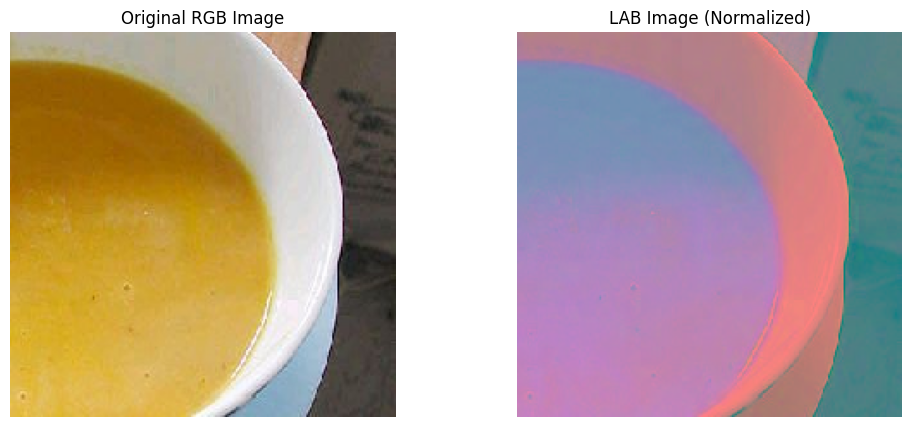

In [15]:
#Проверка преобразования первого изображения в батче
original_img = batch[0]
lab_img = rgb2lab(original_img)

print("Original image (RGB) pixel [0,0]:", original_img[0, 0])
print("Converted image (LAB) pixel [0,0]:", lab_img[0, 0])

# Визуализация изображений
def show_images(rgb_img, lab_img):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(rgb_img)
    axes[0].set_title("Original RGB Image")
    axes[0].axis('off')

    lab_img_visual = (lab_img + [0, 128, 128]) / [100, 255, 255]  # Нормализация для визуализации
    axes[1].imshow(lab_img_visual)
    axes[1].set_title("LAB Image (Normalized)")
    axes[1].axis('off')

    plt.show()

show_images(original_img, lab_img)

In [16]:
# Создается пустой список для хранения признаков, извлеченных с помощью VGG
vggfeatures = []

# Перебираются образцы в наборе данных X
for i, sample in enumerate(X):
  # Конвертируется одноканальное изображение в трехканальное (RGB)
  sample = gray2rgb(sample)
  # Изменяется форма образца для соответствия входу сети VGG16
  sample = sample.reshape((1,224,224,3))
  # Производится предварительная обработка образца для сети VGG16
  sample = keras.applications.vgg16.preprocess_input(sample)
  # Получается предсказание модели для обработанного образца
  prediction = newmodel.predict(sample)
  # Изменяется форма предсказания для соответствия выходу сети VGG16
  prediction = prediction.reshape((7,7,512))
  # Добавляется предсказание в список признаков
  vggfeatures.append(prediction)

# Преобразуется список признаков в NumPy массив
vggfeatures = np.array(vggfeatures)
# Выводится форма массива признаков
print(vggfeatures.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 588ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 626ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 994ms/step
(5, 7, 7, 512)


In [17]:
#Decoder
model = Sequential()

model.add(Conv2D(256, (3,3), activation='relu', padding='same', input_shape=(7,7,512)))
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(16, (3,3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(2, (3, 3), activation='tanh', padding='same'))
model.add(UpSampling2D((2, 2)))
model.summary()


model.compile(optimizer='Adam', loss='mse' , metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 7, 7, 256)      │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 2)    │           290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 224, 224, 2)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,572,114 (6.00 MB)

 Trainable params: 1,572,114 (6.00 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.fit(vggfeatures, Y, verbose=1, epochs=1000, batch_size=256)

model.save('/content/drive/MyDrive/neural_networks/6lab/colorize_autoencoder_VGG16_1.keras')

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.7973 - loss: 0.6208
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.2310 - loss: 0.8715
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.7873 - loss: 0.7492
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.8028 - loss: 0.7329
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.8120 - loss: 0.5600
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.7729 - loss: 0.7085
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.7284 - loss: 0.7142
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.7673 - loss: 0.6835
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.8098 - loss: 0.6031
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.8113 - loss: 0.5404
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.8075 - loss: 0.4827
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - 

In [19]:
model = tf.keras.models.load_model('/content/drive/MyDrive/neural_networks/6lab/colorize_autoencoder_VGG16_1.keras',
                                   custom_objects=None,
                                   compile=True)

In [20]:
import zipfile
import os

zip_path = 'drive/MyDrive/neural_networks/6lab/val.zip'
extract_dir = 'drive/MyDrive/neural_networks/6lab/'

# Создаем папку для распаковки, если её нет
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

# Распаковка архива
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

In [21]:
from skimage.transform import resize
from skimage.io import imsave
from keras.utils import img_to_array, load_img
import os

# Тестирование обученной модели на пользовательских данных
testpath = 'drive/MyDrive/neural_networks/6lab/val'

# Получаем список файлов, исключая директории
files = [f for f in os.listdir(testpath) if os.path.isfile(os.path.join(testpath, f))]

# Если изображения находятся в поддиректориях (как в вашем случае)
# Альтернативный вариант:
image_paths = []
for root, dirs, files in os.walk(testpath):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(root, file))

# Перебираем файлы
for idx, file_path in enumerate(image_paths[:10]):  # Ограничиваем для теста
    try:
        # Загрузка и обработка изображения
        test = img_to_array(load_img(file_path))
        test = resize(test, (224, 224), anti_aliasing=True)
        test *= 1.0 / 255

        # Конвертация в Lab
        lab = rgb2lab(test)
        l = lab[:, :, 0]

        # Подготовка для VGG16
        L = gray2rgb(l).reshape((1, 224, 224, 3))
        L = keras.applications.vgg16.preprocess_input(L)

        # Предсказание
        vggpred = newmodel.predict(L)
        ab = model.predict(vggpred) * 128

        # Сборка цветного изображения
        cur = np.zeros((224, 224, 3))
        cur[:, :, 0] = l
        cur[:, :, 1:] = ab[0]  # Берем первый элемент батча

        # Сохранение
        cur_rgb = (lab2rgb(cur) * 255).astype(np.uint8)
        imsave(f'/content/drive/MyDrive/neural_networks/6lab/result_{idx}.jpg', cur_rgb)

    except Exception as e:
        print(f"Ошибка при обработке {file_path}: {str(e)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step


<ipython-input-21-2035ef38b1f7>:46: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 199 negative Z values that have been clipped to zero
  cur_rgb = (lab2rgb(cur) * 255).astype(np.uint8)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 616ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


<ipython-input-21-2035ef38b1f7>:46: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 996 negative Z values that have been clipped to zero
  cur_rgb = (lab2rgb(cur) * 255).astype(np.uint8)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


<ipython-input-21-2035ef38b1f7>:46: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 32 negative Z values that have been clipped to zero
  cur_rgb = (lab2rgb(cur) * 255).astype(np.uint8)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 563ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


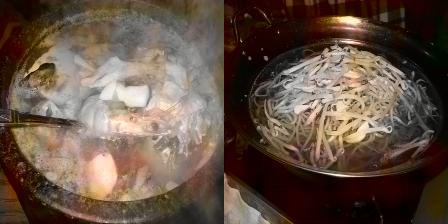

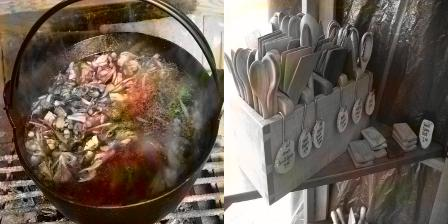

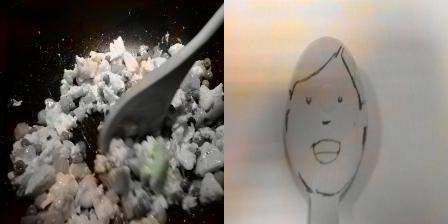

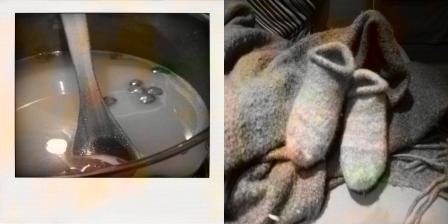

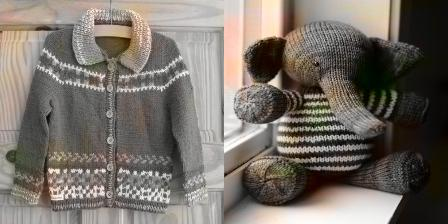

In [22]:
#Вывод результатов:
from google.colab.patches import cv2_imshow
import numpy as np


imo_1 = cv2.imread("/content/drive/MyDrive/neural_networks/6lab/result_0.jpg")
im_1 = cv2.imread("/content/drive/MyDrive/neural_networks/6lab/result_1.jpg")
imo_2 = cv2.imread("/content/drive/MyDrive/neural_networks/6lab/result_2.jpg")
im_2 = cv2.imread("/content/drive/MyDrive/neural_networks/6lab/result_3.jpg")
imo_3 = cv2.imread("/content/drive/MyDrive/neural_networks/6lab/result_4.jpg")
im_3 = cv2.imread("/content/drive/MyDrive/neural_networks/6lab/result_5.jpg")
imo_4 = cv2.imread("/content/drive/MyDrive/neural_networks/6lab/result_6.jpg")
im_4 = cv2.imread("/content/drive/MyDrive/neural_networks/6lab/result_7.jpg")
imo_5 = cv2.imread("/content/drive/MyDrive/neural_networks/6lab/result_8.jpg")
im_5 = cv2.imread("/content/drive/MyDrive/neural_networks/6lab/result_9.jpg")

pred_1 = np.concatenate((imo_1, im_1), axis=1)
pred_2 = np.concatenate((imo_2, im_2), axis=1)
pred_3 = np.concatenate((imo_3, im_3), axis=1)
pred_4 = np.concatenate((imo_4, im_4), axis=1)
pred_5 = np.concatenate((imo_5, im_5), axis=1)

cv2_imshow(pred_1)
cv2_imshow(pred_2)
cv2_imshow(pred_3)
cv2_imshow(pred_4)
cv2_imshow(pred_5)

# Задание №2. Реализуйте автоэнкодер для удаления шума на однотипных изображениях

1.  Подберите датасет, состоящий из однотипных изображений, которые в реальной жизни часто подвержены зашумлению, например спутниковые снимки, ночные фотографии и т.д.

2.  Затем примените к ним операцию зашумления и обучите модель. Также учитывайте тип шума, который Вы применяете. Он должен быть приближен к естественному.

Хороший пример реализации подобной задачи: https://www.kaggle.com/code/michalbrezk/denoise-images-using-autoencoders-tf-keras

In [23]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from keras.datasets import cifar100

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import zipfile
import os

zip_path = 'drive/MyDrive/neural_networks/6lab/noise/night_real.zip'
extract_dir = 'drive/MyDrive/neural_networks/6lab/noise/'

# Создаем папку для распаковки, если её нет
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

# Распаковка архива
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

In [30]:
# Собираем список путей к каждому изображению и перемешиваем их
imagePaths = sorted(list(paths.list_images("drive/MyDrive/neural_networks/6lab/noise/night_real")))
print(imagePaths[10].split(os.path.sep)[-2])
random.shuffle(imagePaths)

night_real


In [31]:
imagePaths = sorted(list(paths.list_images("drive/MyDrive/neural_networks/6lab/noise/night_real")))
print(f"Количество найденных изображений: {len(imagePaths)}")

Количество найденных изображений: 105


In [32]:
data_dir = pathlib.Path("drive/MyDrive/neural_networks/6lab/noise/night_real/")

In [33]:
def preprocess(images, shape):
  """
  Нормализует предоставленный массив и преобразует его в соответствующий формат.

  """

  proc_images = []
  for image in images:
      proc_image = cv2.imread(image)
      proc_image = cv2.resize(proc_image,  (shape[0], shape[1]))
      proc_images.append(proc_image)

  proc_images = np.array(proc_images).astype("float32") / 255.0
  return proc_images


def noise(array):
    """
    Добавляет случайный шум к каждому изображению в предоставленном массиве.

    """

    noise_factor = 0.1
    noisy_array = array + noise_factor * np.random.normal(
        loc=0.0, scale=1.0, size=array.shape
    )

    return np.clip(noisy_array, 0.0, 1.0)


def display(array1, array2):
    """
    Отображает десять случайных изображений из каждого из предоставленных массивов.
    """
    n = 10
    indices = np.random.randint(len(array1), size=n)
    images1 = array1[indices, :]
    images2 = array2[indices, :]

    plt.figure(figsize=(20, 4))
    for i, (image1, image2) in enumerate(zip(images1, images2)):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(image1)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(image2)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

In [34]:
# инициализируем данные и метки
data = []

In [35]:
# Собираем список путей к каждому изображению и перемешиваем их
imagePaths = sorted(list(paths.list_images(data_dir)))
random.shuffle(imagePaths)

In [36]:
img_h = 96 # Высота изображения в пикселях
img_w = 96 # Ширина изображения в пикселях
img_ch = 3 # Количество каналов в изображении

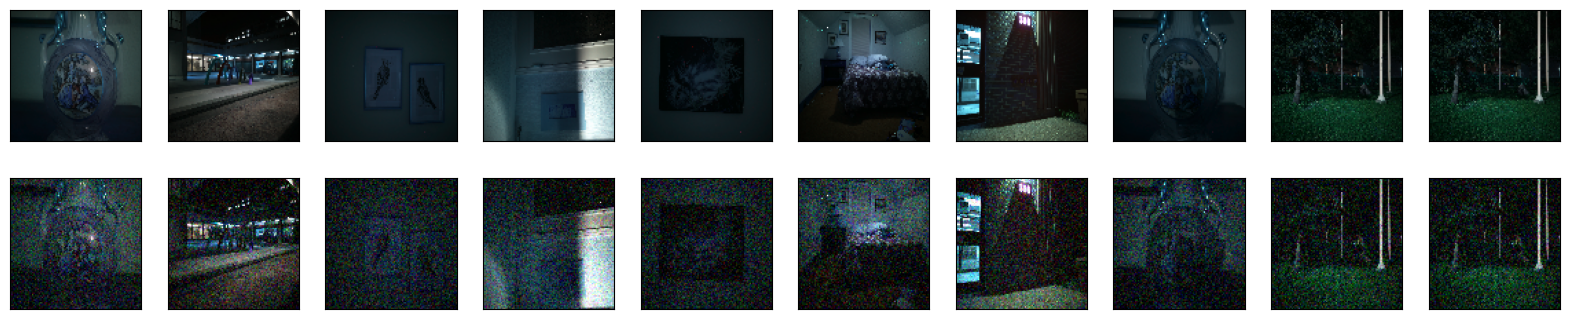

In [37]:
# Нормализация и изменение формы данных
data = preprocess(imagePaths, (img_h,img_w,img_ch))
# Создание копии данных с добавленным шумом
noisy_data = noise(data)

# Отображение данных выборки и его версии с добавленным шумом
display(data, noisy_data)

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
# Поскольку для кодирования и декодирования нам нужны только изображения из набора данных, мы
# не будем использовать метки классов

train_data, val_data, train_noisy_data, val_noisy_data = train_test_split(data, noisy_data, test_size=0.2, random_state=42)


print("Train Data Shape:", train_data.shape)
print("Validation Data Shape:", val_data.shape)
print("Train Noisy Data Shape:", train_noisy_data.shape)
print("Validation Noisy Data Shape:", val_noisy_data.shape)

Train Data Shape: (84, 96, 96, 3)
Validation Data Shape: (21, 96, 96, 3)
Train Noisy Data Shape: (84, 96, 96, 3)
Validation Noisy Data Shape: (21, 96, 96, 3)


In [40]:
input = layers.Input(shape=(96, 96, 3))

# Encoder
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)

# Decoder
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2D(3, (3, 3), activation="sigmoid", padding="same")(x)

# Autoencoder
autoencoder = Model(input, x)
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()

Model: "functional_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 48, 48, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 96, 96, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 96, 96, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,507 (115.26 KB)

 Trainable params: 29,507 (115.26 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
autoencoder.fit(
    x=train_data,
    y=train_data,
    epochs=50,
    batch_size=15,
    shuffle=True,
    validation_data=(val_data, val_data),
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 663ms/step - loss: 0.6896 - val_loss: 0.6714
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 453ms/step - loss: 0.6604 - val_loss: 0.6011
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 667ms/step - loss: 0.5849 - val_loss: 0.5723
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 480ms/step - loss: 0.5564 - val_loss: 0.5294
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 477ms/step - loss: 0.5110 - val_loss: 0.4996
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 791ms/step - loss: 0.4758 - val_loss: 0.4653
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 858ms/step - loss: 0.4311 - val_loss: 0.4228
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 614ms/step - loss: 0.3921 - val_loss: 0.3962
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 593ms/step - loss: 0.3626 - val_loss: 0.3889
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - loss: 0.3667 - val_loss: 0.3870
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 540ms/step - loss: 0.3720 - val_loss: 0.3838
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 657ms/step - loss: 0.3638 - val_loss:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step


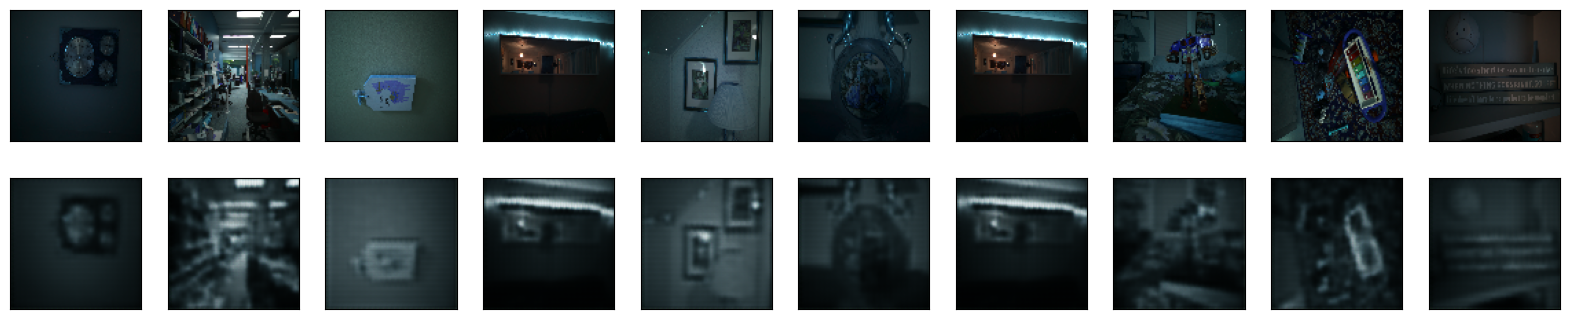

In [42]:
predictions = autoencoder.predict(val_data)
display(val_data, predictions)

In [43]:
autoencoder.fit(
    x=train_noisy_data,
    y=train_data,
    epochs=50,
    batch_size=15,
    shuffle=True,
    validation_data=(val_noisy_data, val_data),
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 451ms/step - loss: 0.3375 - val_loss: 0.3647
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 667ms/step - loss: 0.3380 - val_loss: 0.3639
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 463ms/step - loss: 0.3301 - val_loss: 0.3632
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 431ms/step - loss: 0.3472 - val_loss: 0.3631
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 739ms/step - loss: 0.3340 - val_loss: 0.3630
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 422ms/step - loss: 0.3404 - val_loss: 0.3629
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 492ms/step - loss: 0.3453 - val_loss: 0.3628
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 764ms/step - loss: 0.3395 - val_loss: 0.3628
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 421ms/step - loss: 0.3328 - val_loss: 0.3627
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 440ms/step - loss: 0.3411 - val_loss: 0.3626
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 676ms/step - loss: 0.3420 - val_loss: 0.3626
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 521ms/step - loss: 0.3456 - val_lo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


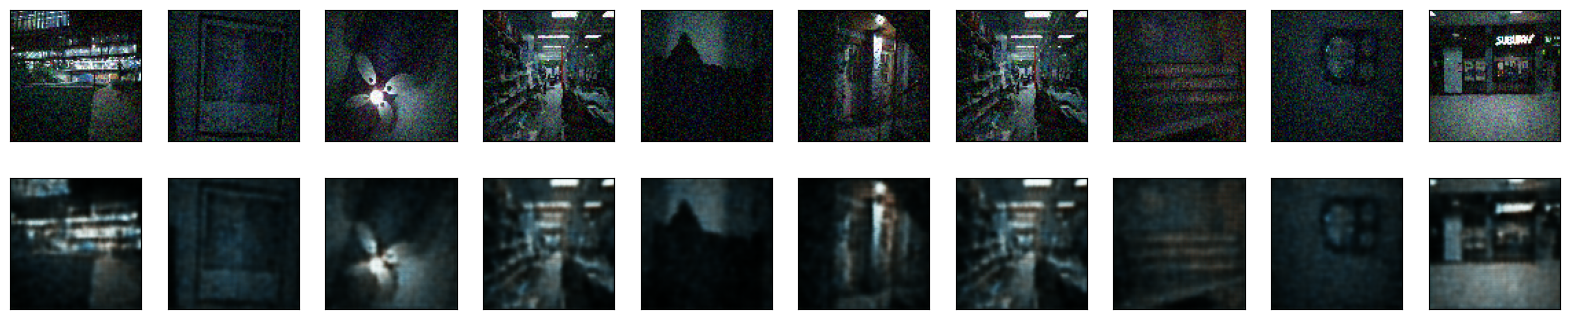

In [47]:
predictions = autoencoder.predict(val_noisy_data)
display(val_noisy_data, predictions)

# Задание №.3 Реализуйте автоэнкодер для улучшения качества изображения путём увеличения его разрешения (апскейлинг-[определение](https://dic.academic.ru/dic.nsf/ruwiki/346555))

1. На входной слой нейронной сети подаётся изображение с размерностью (256, 256,3) - X_test. В результате работы нейронной сети на выходном слое должно получиться изображение (512, 512, 3) - Y_test. В итоге мы получаем двукратный апскейл исходного изображения.

2. Датасет собираете из изображений, разрешение которых выше эталонного (512,512,3). Затем преобразуете их в указанные размерности и формируете из них обучающую и проверочную выборку.

3. Обучите модель. Отобразите графики обучения

4. Подумайте, каким образом можно будет адаптировать модель вашей нейронной сети для двухратного апскейла изображения с любой размерностью, большей, чем (256,256,3), с полным или частичным сохранением его исходных пропорций. Например: подаём на вход изображение с разрешением (1920, 1080, 3) - получаем изображение с разрешением (3840, 2160, 3), т.е. с полным сохранением исходных пропорций или (1792, 1024, 3) с частичным сохранением исходных пропорций.

> Подсказка: Для этого можно реализовать алгоритм предварительной обработки исходного изображения, перед подачей его в нейронную сеть

In [48]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten
from keras.optimizers import SGD, Adam
from imutils import paths
import matplotlib.pyplot as plt
import numpy as np
import random
import pickle
import cv2
import os

from google.colab.patches import cv2_imshow

from tensorflow import keras
from google.colab import files
from io import BytesIO
from PIL import Image
from urllib.request import urlopen
from imutils import paths
import tensorflow as tf

In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
import zipfile
import os

zip_path = 'drive/MyDrive/neural_networks/6lab/upscale/upsc.zip'
extract_dir = 'drive/MyDrive/neural_networks/6lab/upscale/'

# Создаем папку для распаковки, если её нет
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

# Распаковка архива
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

In [71]:
# Собираем список путей к каждому изображению и перемешиваем их
imagePaths = sorted(list(paths.list_images("/content/drive/MyDrive/neural_networks/6lab/upscale/uosc")))
print(imagePaths)
print(imagePaths[10].split(os.path.sep)[-2])
random.shuffle(imagePaths)

['/content/drive/MyDrive/neural_networks/6lab/upscale/uosc/11800.jpg', '/content/drive/MyDrive/neural_networks/6lab/upscale/uosc/11801.jpg', '/content/drive/MyDrive/neural_networks/6lab/upscale/uosc/11802.jpg', '/content/drive/MyDrive/neural_networks/6lab/upscale/uosc/11803.jpg', '/content/drive/MyDrive/neural_networks/6lab/upscale/uosc/11804.jpg', '/content/drive/MyDrive/neural_networks/6lab/upscale/uosc/11805.jpg', '/content/drive/MyDrive/neural_networks/6lab/upscale/uosc/11806.jpg', '/content/drive/MyDrive/neural_networks/6lab/upscale/uosc/11807.jpg', '/content/drive/MyDrive/neural_networks/6lab/upscale/uosc/11808.jpg', '/content/drive/MyDrive/neural_networks/6lab/upscale/uosc/11809.jpg', '/content/drive/MyDrive/neural_networks/6lab/upscale/uosc/11810.jpg', '/content/drive/MyDrive/neural_networks/6lab/upscale/uosc/11811.jpg', '/content/drive/MyDrive/neural_networks/6lab/upscale/uosc/11812.jpg', '/content/drive/MyDrive/neural_networks/6lab/upscale/uosc/11813.jpg', '/content/drive/MyD

In [72]:
imagePaths = sorted(list(paths.list_images("/content/drive/MyDrive/neural_networks/6lab/upscale/uosc")))
print(f"Количество найденных изображений: {len(imagePaths)}")

Количество найденных изображений: 231


In [73]:
def load_images(imagePaths, compression_size = 256):
  data = []
  half_length = len(imagePaths) // 4
  for imagePath in imagePaths[:half_length]:
    # Загрузка изображения
    image = cv2.imread(imagePath)
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    image = cv2.resize(image, (compression_size, compression_size))

    # Добавление изображения в список
    data.append(image)

  return data

data = load_images(imagePaths, 256)
data = np.array(data, dtype="float") / 255.0

In [74]:
def load_orig(imagePaths, compression_size = 512):
  data = []
  half_length = len(imagePaths) // 4
  for imagePath in imagePaths[:half_length]:
    # Загрузка изображения
    image = cv2.imread(imagePath)
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    image = cv2.resize(image, (compression_size, compression_size))
    # Добавление изображения в список
    data.append(image)

  return data
orig = load_orig(imagePaths, 512)
orig = np.array(orig, dtype="float") / 255.0

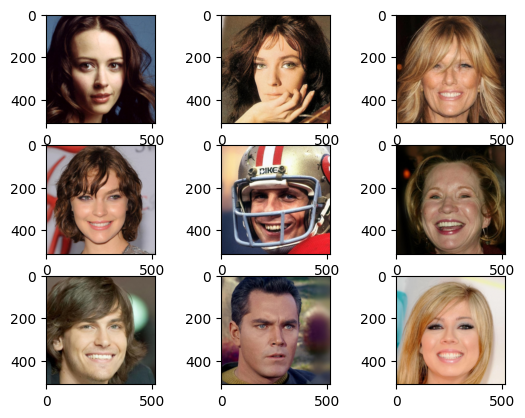

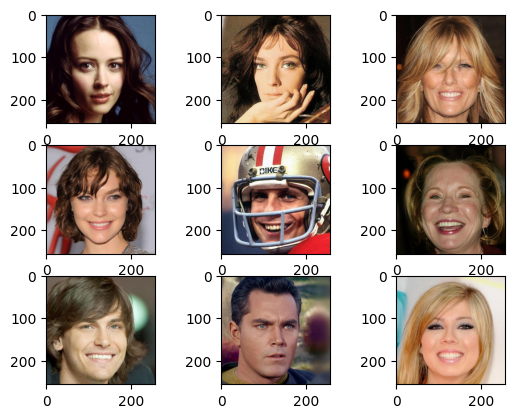

In [75]:
import matplotlib.pyplot as plt

for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.imshow(orig[i], cmap=plt.get_cmap('gray'))

plt.show()

for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.imshow(data[i], cmap=plt.get_cmap('gray'))

plt.show()

In [76]:
(trainX, valX) = train_test_split(data, test_size=0.25, random_state=28)
(origTrainX, origValX) = train_test_split(orig, test_size=0.25, random_state=28)
print(trainX)
print(valX)
print(origTrainX)
print(origValX)

[[[[0.81960784 0.82745098 0.82352941]
   [0.82352941 0.83137255 0.82745098]
   [0.81568627 0.82352941 0.81960784]
   ...
   [0.89411765 0.85098039 0.83529412]
   [0.89411765 0.85098039 0.83529412]
   [0.89411765 0.85098039 0.83529412]]

  [[0.81568627 0.82352941 0.81960784]
   [0.82352941 0.83137255 0.82745098]
   [0.82352941 0.83137255 0.82745098]
   ...
   [0.89411765 0.85098039 0.83529412]
   [0.89411765 0.85098039 0.83529412]
   [0.89411765 0.85098039 0.83529412]]

  [[0.81568627 0.82352941 0.81960784]
   [0.82352941 0.83137255 0.82745098]
   [0.82352941 0.83137255 0.82745098]
   ...
   [0.89803922 0.85490196 0.83921569]
   [0.89803922 0.85490196 0.83921569]
   [0.89803922 0.85490196 0.83921569]]

  ...

  [[0.5372549  0.3372549  0.12941176]
   [0.60784314 0.40784314 0.19215686]
   [0.64705882 0.44705882 0.23137255]
   ...
   [0.94901961 0.91764706 0.8745098 ]
   [0.95294118 0.92156863 0.87843137]
   [0.96078431 0.92941176 0.88627451]]

  [[0.52941176 0.32156863 0.1254902 ]
   [0.6

In [77]:
# Encoder
from keras.layers import Input, Conv2D, UpSampling2D
from keras.optimizers import Adam
from keras import layers
from keras.models import Model


# Гиперпараметры
input_shape = (256, 256, 3)
output_shape = (512, 512, 3)
batch_size = 15

# Создание модели автоэнкодера
input_img = Input(shape=input_shape)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(input_img)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D()(x)
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder3 = Model(input_img, decoded)
autoencoder3.compile(optimizer='adam', loss='mse')

In [78]:
# обучаем модель
history = autoencoder3.fit(trainX,
                origTrainX,
                epochs=10,
                batch_size=batch_size,
                shuffle=True,
                validation_data=(valX, origValX))

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 76s 24s/step - loss: 0.0853 - val_loss: 0.0718
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 78s 24s/step - loss: 0.0811 - val_loss: 0.0739
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 74s 25s/step - loss: 0.0720 - val_loss: 0.0631
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 77s 23s/step - loss: 0.0653 - val_loss: 0.0497
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 23s/step - loss: 0.0615 - val_loss: 0.0441
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 89s 26s/step - loss: 0.0533 - val_loss: 0.0331
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 77s 24s/step - loss: 0.0419 - val_loss: 0.0228
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 92s 28s/step - loss: 0.0298 - val_loss: 0.0153
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 74s 25s/step - loss: 0.0194 - val_loss: 0.0094
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 78s 24s/step - loss: 0.0102 - val_loss: 0.0051


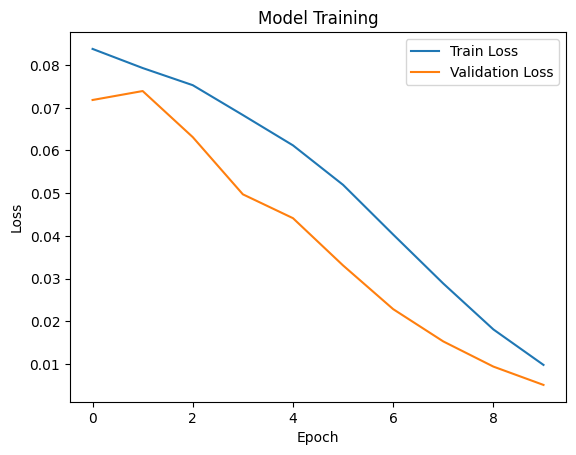

In [79]:
# строим график обучения
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [80]:
autoencoder3.save("/content/drive/MyDrive/neural_networks/6lab/upscale/autoencoder_upscale.keras")

In [81]:
import cv2
# load an image
img = cv2.imread('/content/drive/MyDrive/neural_networks/6lab/upscale/uosc/514.jpg')
# get the dimensions of the image
height, width, channels = img.shape
print(f"Image dimensions: {width}x{height}, {channels} channels")

Image dimensions: 256x256, 3 channels


2/2 ━━━━━━━━━━━━━━━━━━━━ 19s 9s/step


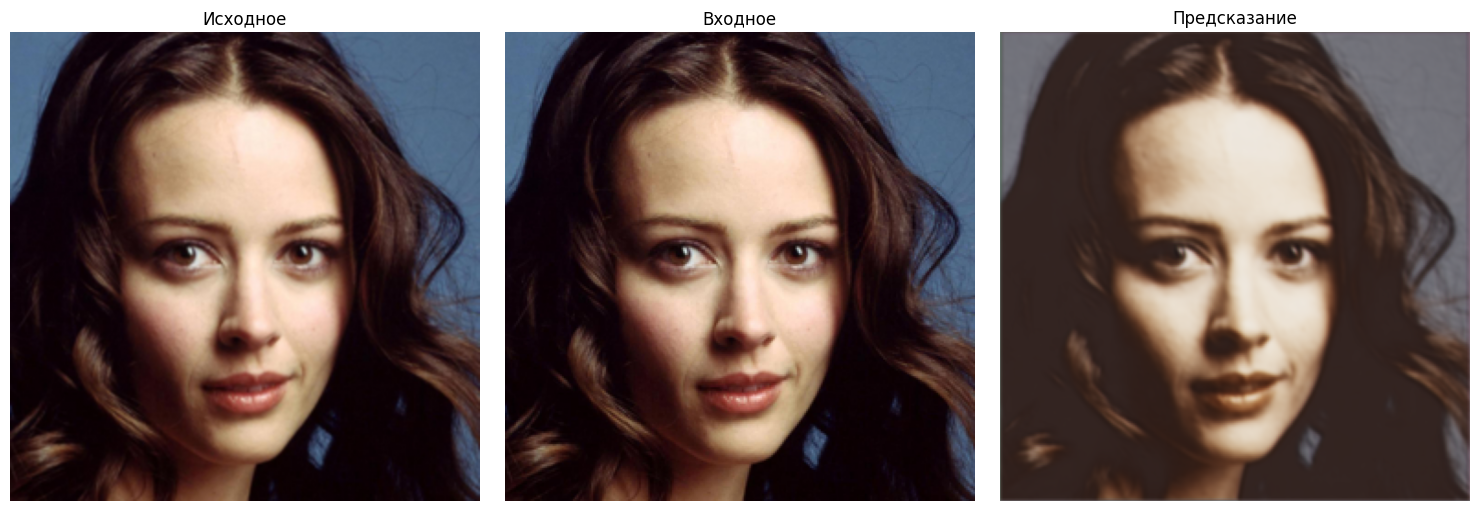

In [82]:
import matplotlib.pyplot as plt

index = 1

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Отображение оригинального изображения
axs[0].imshow(orig[index], cmap=plt.get_cmap('gray'))
axs[0].set_title('Исходное')
axs[0].axis('off')

# Отображение входного изображения
axs[1].imshow(data[index], cmap=plt.get_cmap('gray'))
axs[1].set_title('Входное')
axs[1].axis('off')  # Убираем оси

predictions = autoencoder3.predict(data)

# Отображение предсказанного изображения
axs[2].imshow(predictions[index], cmap=plt.get_cmap('gray'))
axs[2].set_title('Предсказание')
axs[2].axis('off')

# Показать изображения
plt.tight_layout()
plt.show()